# Notebook 05: Feature Explanations

## Objective

This notebook generates explanation outputs for TrustLens using the best-performing model. It produces global feature importance, SHAP summary plots, and local explanations for selected fraud and non-fraud transactions.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR = Path("../results/figures")
METRICS_DIR = Path("../results/metrics")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

X_test = pd.read_csv(DATA_DIR / "X_test_processed.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

lgbm_model = joblib.load(MODELS_DIR / "lightgbm.pkl")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (118108, 420)
y_test: (118108,)


In [3]:
X_explain = X_test.sample(n=500, random_state=42)
y_explain = y_test.loc[X_explain.index]

print("Explanation sample:", X_explain.shape)
print("Fraud cases:", int(y_explain.sum()))

Explanation sample: (500, 420)
Fraud cases: 14


In [4]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print("SHAP values prepared.")

SHAP values prepared.


/Users/user/Documents/trustlens/venv312/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


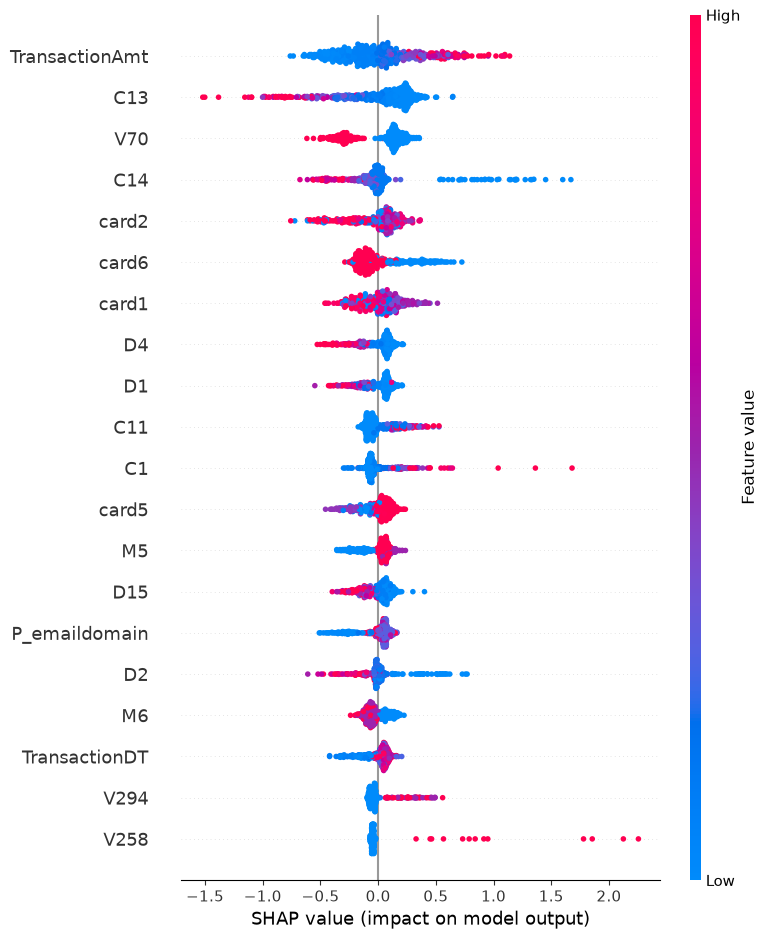

In [4]:
shap.summary_plot(
    shap_values_plot,
    X_explain,
    show=False
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lightgbm_shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

top_20_features = feature_importance.head(20).rename(columns={
    "mean_absolute_shap_value": "mean_abs_shap"
})

top_20_features.to_csv(
    METRICS_DIR / "lightgbm_top_20_shap_features.csv",
    index=False
)

top_20_features

,feature,mean_abs_shap
1,TransactionAmt,0.261412
21,C13,0.254821
106,V70,0.203389
22,C14,0.176943
393,card6,0.145918
2,card1,0.145786
3,card2,0.145172
0,TransactionDT,0.131675
23,D1,0.115494
9,C1,0.114117


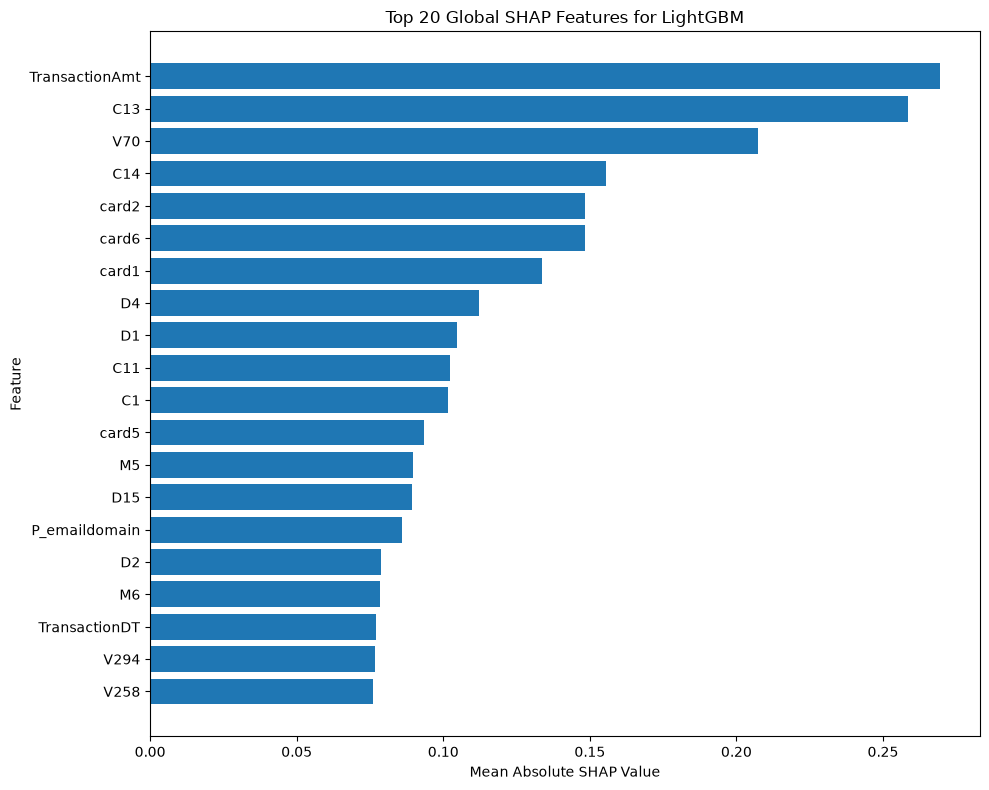

In [6]:
plt.figure(figsize=(10, 8))
plt.barh(
    top_20_features["feature"][::-1],
    top_20_features["mean_abs_shap"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Global SHAP Features for LightGBM")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lightgbm_top_20_shap_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Get model predictions for the explanation sample

y_pred_proba = lgbm_model.predict_proba(X_explain)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

explain_results = X_explain.copy()
explain_results["actual_isFraud"] = y_explain.values
explain_results["predicted_isFraud"] = y_pred
explain_results["fraud_probability"] = y_pred_proba

explain_results[["actual_isFraud", "predicted_isFraud", "fraud_probability"]].head()

,actual_isFraud,predicted_isFraud,fraud_probability
9562,0,0,0.104259
62859,0,0,0.122717
6330,0,0,0.334191
6288,0,0,0.017389
43799,0,0,0.063405


In [ ]:
# Cell 8 - Select one correctly predicted fraud case

fraud_cases = explain_results[
    (explain_results["actual_isFraud"] == 1) &
    (explain_results["predicted_isFraud"] == 1)
]

fraud_case_index = fraud_cases.index[0]

print("Selected fraud case index:", fraud_case_index)
print("Fraud probability:", explain_results.loc[fraud_case_index, "fraud_probability"])

Selected fraud case index: 101443
Fraud probability: 0.9921661982811046


In [9]:
# Local SHAP explanation for the selected fraud case

fraud_position = list(X_explain.index).index(fraud_case_index)

local_shap_values = shap_values_plot[fraud_position]
local_feature_values = X_explain.loc[fraud_case_index]

local_explanation = pd.DataFrame({
    "feature": X_explain.columns,
    "feature_value": local_feature_values.values,
    "shap_value": local_shap_values
})

local_explanation["absolute_shap_value"] = local_explanation["shap_value"].abs()

top_local_fraud_features = local_explanation.sort_values(
    "absolute_shap_value",
    ascending=False
).head(15)

top_local_fraud_features.to_csv(
    METRICS_DIR / "local_explanation_fraud_case.csv",
    index=False
)

top_local_fraud_features

,feature,feature_value,shap_value,absolute_shap_value
295,V258,5.0,2.124780,2.124780
23,C14,0.0,0.543906,0.543906
238,V201,3.0,0.447995,0.447995
22,C13,0.0,0.413643,0.413643
226,V189,3.0,0.412139,0.412139
124,V87,5.0,0.294618,0.294618
20,C11,3.0,0.232579,0.232579
224,V187,3.0,0.232176,0.232176
294,V257,5.0,0.221909,0.221909
26,D3,0.0,-0.190668,0.190668


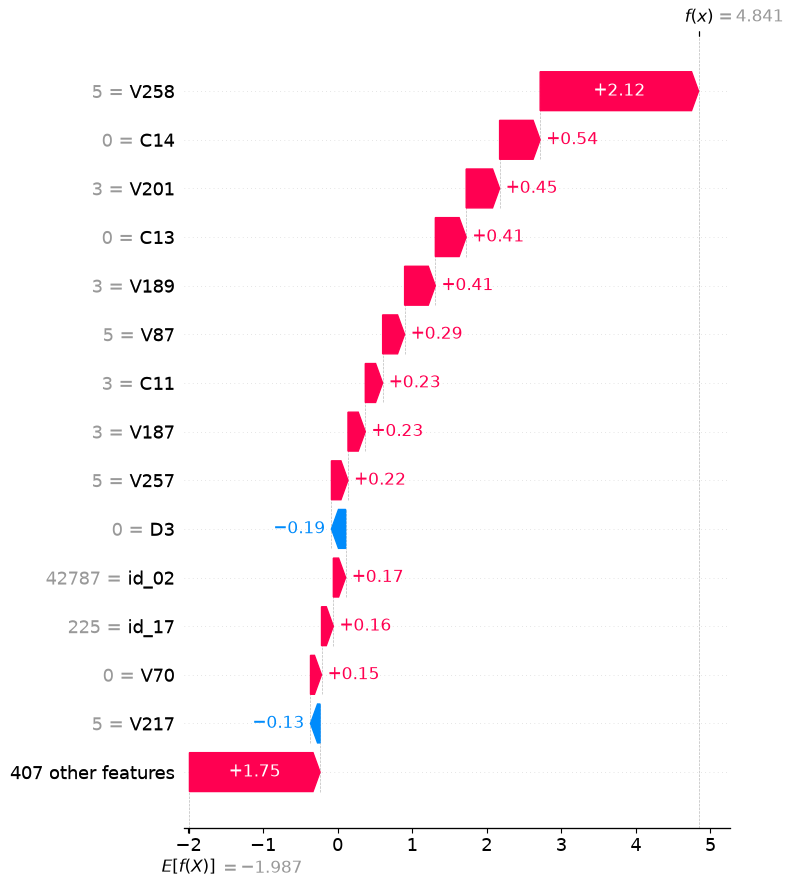

In [10]:
# Waterfall plot for selected fraud case

expected_value = explainer.expected_value

if isinstance(expected_value, list):
    expected_value_plot = expected_value[1]
else:
    expected_value_plot = expected_value

shap_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=expected_value_plot,
    data=local_feature_values.values,
    feature_names=X_explain.columns
)

shap.plots.waterfall(shap_explanation, max_display=15, show=False)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "local_fraud_case_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
# Select one correctly predicted non-fraud case

non_fraud_cases = explain_results[
    (explain_results["actual_isFraud"] == 0) &
    (explain_results["predicted_isFraud"] == 0)
]

non_fraud_case_index = non_fraud_cases.index[0]

print("Selected non-fraud case index:", non_fraud_case_index)
print("Fraud probability:", explain_results.loc[non_fraud_case_index, "fraud_probability"])

Selected non-fraud case index: 9562
Fraud probability: 0.1042594729474696


In [12]:
# Local SHAP explanation for the selected non-fraud case

non_fraud_position = list(X_explain.index).index(non_fraud_case_index)

local_shap_values_non_fraud = shap_values_plot[non_fraud_position]
local_feature_values_non_fraud = X_explain.loc[non_fraud_case_index]

local_explanation_non_fraud = pd.DataFrame({
    "feature": X_explain.columns,
    "feature_value": local_feature_values_non_fraud.values,
    "shap_value": local_shap_values_non_fraud
})

local_explanation_non_fraud["absolute_shap_value"] = local_explanation_non_fraud["shap_value"].abs()

top_local_non_fraud_features = local_explanation_non_fraud.sort_values(
    "absolute_shap_value",
    ascending=False
).head(15)

top_local_non_fraud_features.to_csv(
    METRICS_DIR / "local_explanation_non_fraud_case.csv",
    index=False
)

top_local_non_fraud_features

,feature,feature_value,shap_value,absolute_shap_value
2,TransactionAmt,459.99,0.691873,0.691873
107,V70,1.00,-0.360372,0.360372
4,card2,555.00,-0.277377,0.277377
27,D4,0.00,0.153973,0.153973
400,M4,3.00,-0.144583,0.144583
22,C13,1.00,0.144184,0.144184
128,V91,1.00,-0.122337,0.122337
85,V48,1.00,-0.116406,0.116406
394,card6,2.00,-0.114888,0.114888
24,D1,0.00,0.114176,0.114176


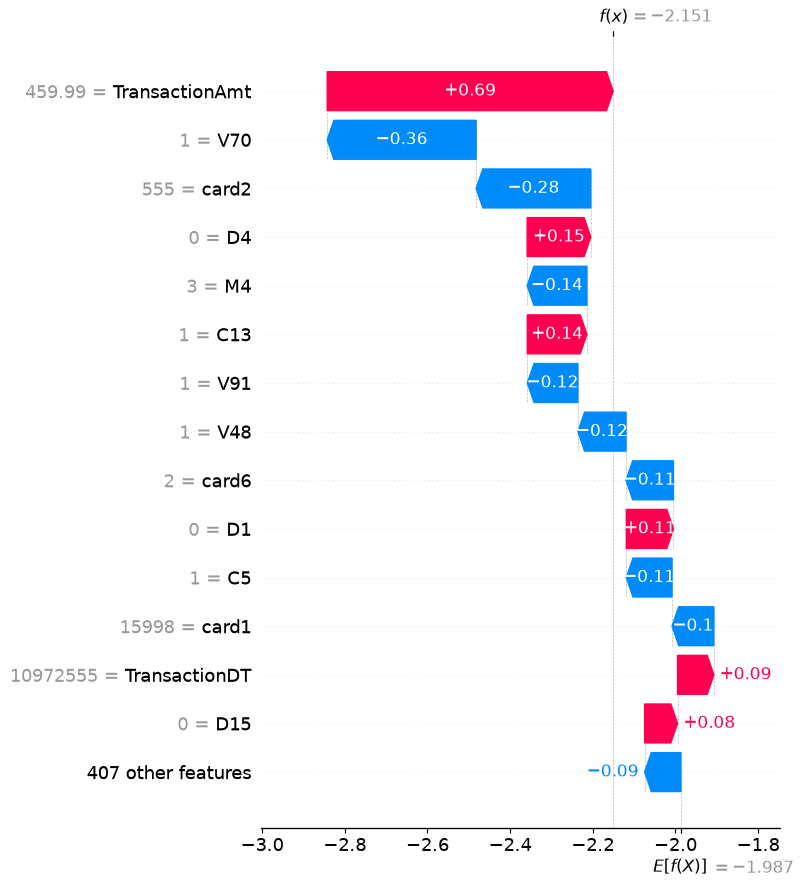

In [13]:
# Waterfall plot for selected non-fraud case

shap_explanation_non_fraud = shap.Explanation(
    values=local_shap_values_non_fraud,
    base_values=expected_value_plot,
    data=local_feature_values_non_fraud.values,
    feature_names=X_explain.columns
)

shap.plots.waterfall(shap_explanation_non_fraud, max_display=15, show=False)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "local_non_fraud_case_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd()

if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

# Corrected 420-feature test data
X_test = pd.read_csv(
    ROOT_DIR / "data" / "processed" / "X_test_processed.csv"
)

y_test = pd.read_csv(
    ROOT_DIR / "data" / "processed" / "y_test.csv"
).squeeze()

# Official corrected LightGBM model
model = joblib.load(
    ROOT_DIR / "models" / "lightgbm.pkl"
)

print("X_test shape:", X_test.shape)
print("Model feature count:", model.n_features_in_)
print("TransactionID included:", "TransactionID" in X_test.columns)

X_test shape: (118108, 420)
Model feature count: 420
TransactionID included: False


In [15]:
X_explain = X_test.sample(
    n=500,
    random_state=42
)

y_explain = y_test.loc[X_explain.index]

print("Explanation sample shape:", X_explain.shape)
print("Fraud cases in sample:", int(y_explain.sum()))

Explanation sample shape: (500, 420)
Fraud cases in sample: 14


In [16]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_explain)

# Some SHAP versions return a list for binary classifiers
if isinstance(shap_values, list):
    shap_values_array = shap_values[1]
else:
    shap_values_array = shap_values

print("SHAP values shape:", shap_values_array.shape)

SHAP values shape: (500, 420)


/Users/user/Documents/trustlens/venv312/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


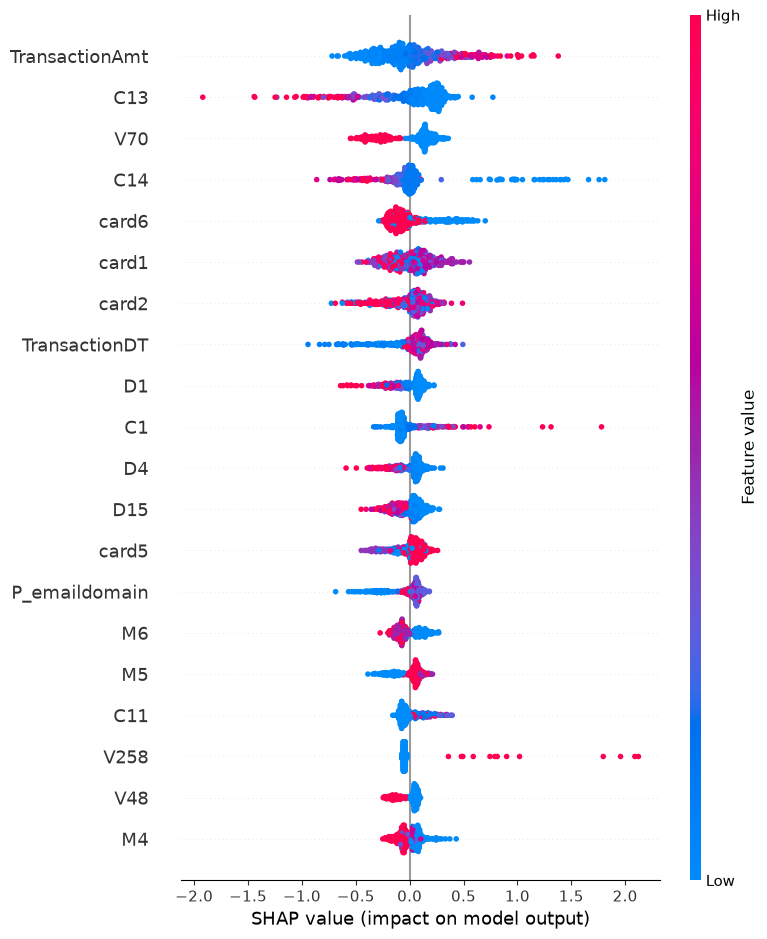

Saved to:
/Users/user/Documents/trustlens/results/figures/lightgbm_shap_summary_plot.png


In [17]:
plt.figure()

shap.summary_plot(
    shap_values_array,
    X_explain,
    show=False
)

plt.tight_layout()

summary_plot_path = (
    ROOT_DIR
    / "results"
    / "figures"
    / "lightgbm_shap_summary_plot.png"
)

plt.savefig(
    summary_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{summary_plot_path}")

In [18]:
mean_abs_shap = np.abs(shap_values_array).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
})

feature_importance_df = feature_importance_df.sort_values(
    "mean_abs_shap",
    ascending=False
)

top_20_features = (
    feature_importance_df.head(20)
    .rename(columns={
        "mean_absolute_shap_value": "mean_abs_shap"
    })
    .reset_index(drop=True)
)

display(top_20_features)

,feature,mean_abs_shap
0,TransactionAmt,0.261412
1,C13,0.254821
2,V70,0.203389
3,C14,0.176943
4,card6,0.145918
5,card1,0.145786
6,card2,0.145172
7,TransactionDT,0.131675
8,D1,0.115494
9,C1,0.114117


In [19]:
top_20_path = (
    ROOT_DIR
    / "results"
    / "metrics"
    / "lightgbm_top_20_shap_features.csv"
)

top_20_features.to_csv(
    top_20_path,
    index=False
)

print(f"Saved to:\n{top_20_path}")

Saved to:
/Users/user/Documents/trustlens/results/metrics/lightgbm_top_20_shap_features.csv


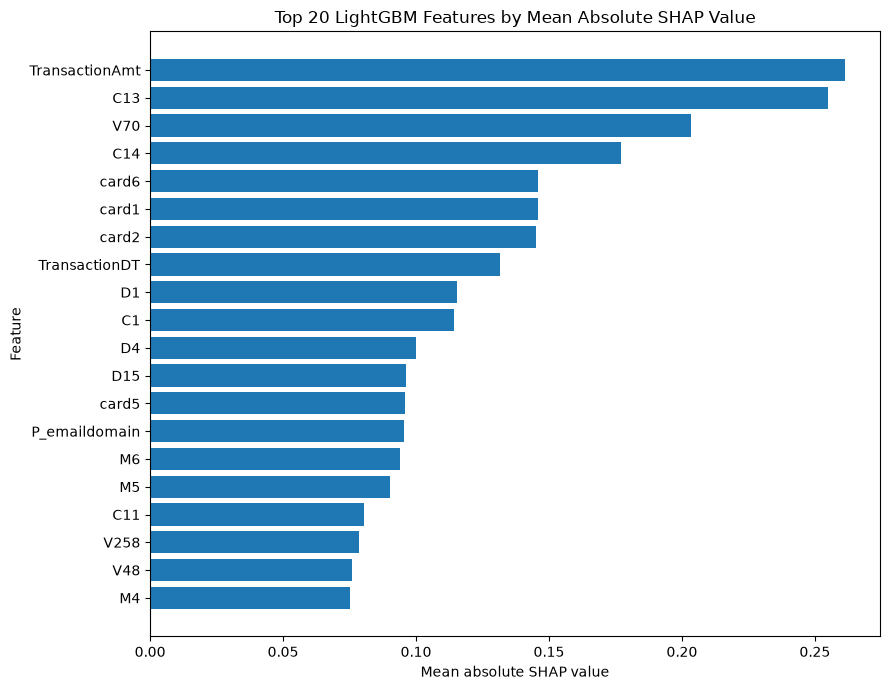

Saved to:
/Users/user/Documents/trustlens/results/figures/lightgbm_top_20_shap_features.png


In [20]:
top_20_plot = top_20_features.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_20_plot["feature"],
    top_20_plot["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Features by Mean Absolute SHAP Value")

plt.tight_layout()

top_20_plot_path = (
    ROOT_DIR
    / "results"
    / "figures"
    / "lightgbm_top_20_shap_features.png"
)

plt.savefig(
    top_20_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{top_20_plot_path}")

In [21]:
fraud_probabilities = model.predict_proba(X_explain)[:, 1]

local_results = pd.DataFrame({
    "actual_label": y_explain.values,
    "fraud_probability": fraud_probabilities
}, index=X_explain.index)

display(
    local_results.sort_values(
        "fraud_probability",
        ascending=False
    ).head(20)
)

,actual_label,fraud_probability
87244,1,0.998309
87165,1,0.993365
101443,1,0.989392
59139,1,0.979178
27261,1,0.955794
18520,1,0.943505
55777,1,0.855007
26494,1,0.833826
103870,0,0.828067
88735,0,0.823330


In [22]:
fraud_candidates = local_results[
    (local_results["actual_label"] == 1)
    & (local_results["fraud_probability"] >= 0.5)
]

fraud_index = fraud_candidates[
    "fraud_probability"
].idxmax()

fraud_position = X_explain.index.get_loc(fraud_index)

print("Selected fraud index:", fraud_index)
print(
    "Fraud probability:",
    local_results.loc[fraud_index, "fraud_probability"]
)

Selected fraud index: 87244
Fraud probability: 0.9983093498463582


In [23]:
fraud_shap_values = shap_values_array[fraud_position]
fraud_feature_values = X_explain.loc[fraud_index]

fraud_local_df = pd.DataFrame({
    "feature": X_explain.columns,
    "feature_value": fraud_feature_values.values,
    "shap_value": fraud_shap_values
})

fraud_local_df["absolute_shap"] = fraud_local_df[
    "shap_value"
].abs()

fraud_local_df = fraud_local_df.sort_values(
    "absolute_shap",
    ascending=False
)

display(
    fraud_local_df.head(15)[
        ["feature", "feature_value", "shap_value"]
    ]
)

,feature,feature_value,shap_value
294,V258,13.0,1.796767
9,C1,20.0,1.233280
81,V45,8.0,0.769340
21,C13,2.0,0.580090
225,V189,5.0,0.364285
20,C12,15.0,0.348879
237,V201,8.0,0.338006
22,C14,2.0,0.293036
19,C11,15.0,0.256070
293,V257,12.0,0.216470


In [24]:
fraud_local_path = (
    ROOT_DIR
    / "results"
    / "metrics"
    / "local_explanation_fraud_case.csv"
)

fraud_local_df.to_csv(
    fraud_local_path,
    index=False
)

print(f"Saved to:\n{fraud_local_path}")

Saved to:
/Users/user/Documents/trustlens/results/metrics/local_explanation_fraud_case.csv


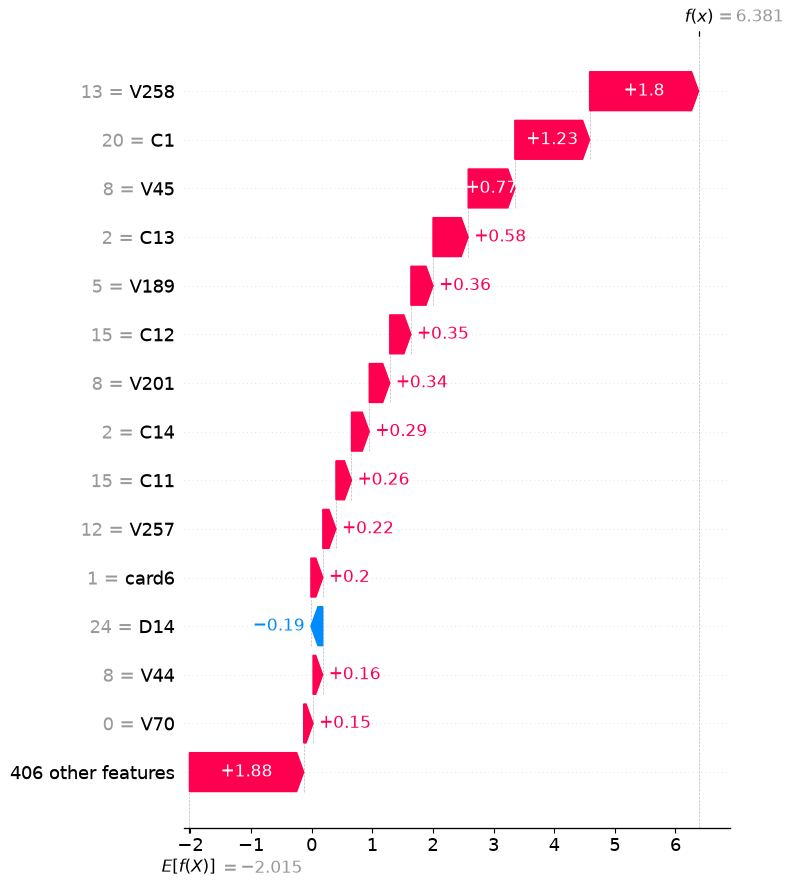

Saved to:
/Users/user/Documents/trustlens/results/figures/local_fraud_case_waterfall.png


In [25]:
fraud_explanation = shap.Explanation(
    values=fraud_shap_values,
    base_values=explainer.expected_value[
        1
    ] if isinstance(explainer.expected_value, (list, np.ndarray))
    and np.ndim(explainer.expected_value) > 0
    and len(np.atleast_1d(explainer.expected_value)) > 1
    else np.atleast_1d(explainer.expected_value)[0],
    data=fraud_feature_values.values,
    feature_names=X_explain.columns
)

shap.plots.waterfall(
    fraud_explanation,
    max_display=15,
    show=False
)

fraud_waterfall_path = (
    ROOT_DIR
    / "results"
    / "figures"
    / "local_fraud_case_waterfall.png"
)

plt.tight_layout()

plt.savefig(
    fraud_waterfall_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{fraud_waterfall_path}")

In [26]:
non_fraud_candidates = local_results[
    (local_results["actual_label"] == 0)
    & (local_results["fraud_probability"] < 0.5)
]

non_fraud_index = non_fraud_candidates[
    "fraud_probability"
].idxmax()

non_fraud_position = X_explain.index.get_loc(
    non_fraud_index
)

print("Selected non-fraud index:", non_fraud_index)
print(
    "Fraud probability:",
    local_results.loc[
        non_fraud_index,
        "fraud_probability"
    ]
)

Selected non-fraud index: 98462
Fraud probability: 0.4936523894973002


In [27]:
non_fraud_shap_values = shap_values_array[
    non_fraud_position
]

non_fraud_feature_values = X_explain.loc[
    non_fraud_index
]

non_fraud_local_df = pd.DataFrame({
    "feature": X_explain.columns,
    "feature_value": non_fraud_feature_values.values,
    "shap_value": non_fraud_shap_values
})

non_fraud_local_df["absolute_shap"] = (
    non_fraud_local_df["shap_value"].abs()
)

non_fraud_local_df = non_fraud_local_df.sort_values(
    "absolute_shap",
    ascending=False
)

display(
    non_fraud_local_df.head(15)[
        ["feature", "feature_value", "shap_value"]
    ]
)

,feature,feature_value,shap_value
22,C14,0.000000e+00,1.468712
29,D8,8.683334e+01,-0.332459
394,P_emaildomain,1.000000e+00,-0.330345
0,TransactionDT,8.799436e+06,0.260608
106,V70,0.000000e+00,0.259377
21,C13,0.000000e+00,0.239542
391,ProductCD,1.000000e+00,0.234792
3,card2,5.830000e+02,-0.209446
386,id_14,-4.200000e+02,-0.170052
381,id_06,-1.300000e+01,0.150252


In [28]:
non_fraud_local_path = (
    ROOT_DIR
    / "results"
    / "metrics"
    / "local_explanation_non_fraud_case.csv"
)

non_fraud_local_df.to_csv(
    non_fraud_local_path,
    index=False
)

print(f"Saved to:\n{non_fraud_local_path}")

Saved to:
/Users/user/Documents/trustlens/results/metrics/local_explanation_non_fraud_case.csv


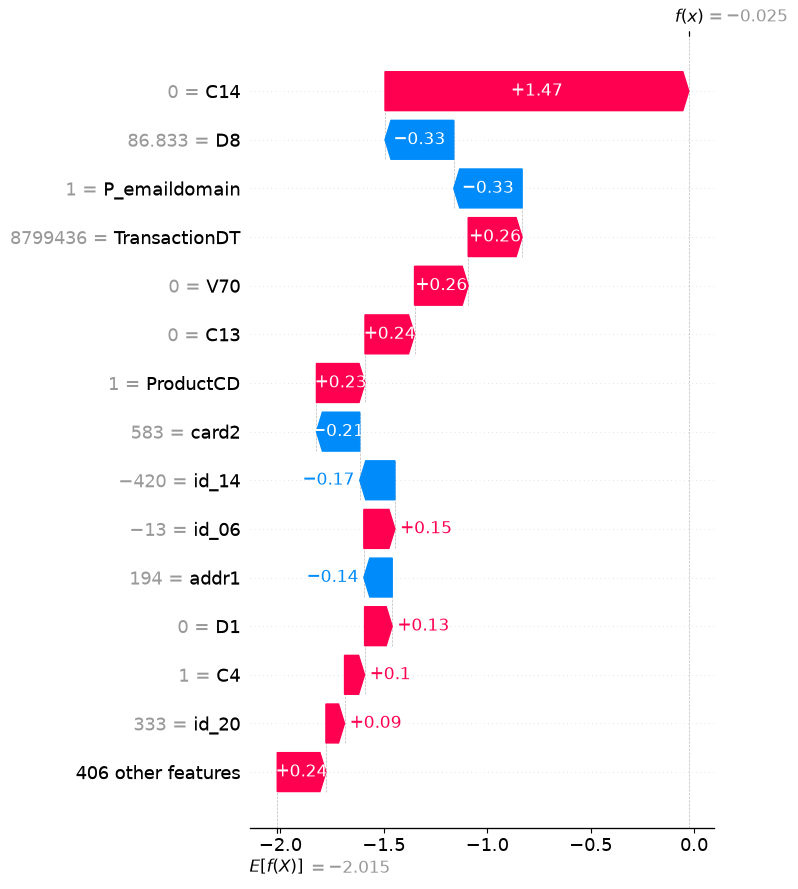

Saved to:
/Users/user/Documents/trustlens/results/figures/local_non_fraud_case_waterfall.png


In [29]:
non_fraud_explanation = shap.Explanation(
    values=non_fraud_shap_values,
    base_values=explainer.expected_value[
        1
    ] if isinstance(explainer.expected_value, (list, np.ndarray))
    and np.ndim(explainer.expected_value) > 0
    and len(np.atleast_1d(explainer.expected_value)) > 1
    else np.atleast_1d(explainer.expected_value)[0],
    data=non_fraud_feature_values.values,
    feature_names=X_explain.columns
)

shap.plots.waterfall(
    non_fraud_explanation,
    max_display=15,
    show=False
)

non_fraud_waterfall_path = (
    ROOT_DIR
    / "results"
    / "figures"
    / "local_non_fraud_case_waterfall.png"
)

plt.tight_layout()

plt.savefig(
    non_fraud_waterfall_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{non_fraud_waterfall_path}")

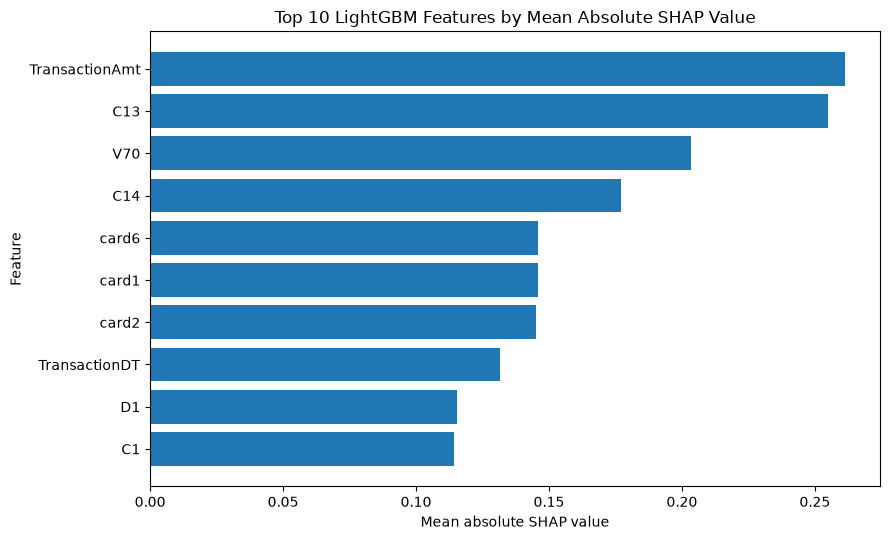

Saved to:
/Users/user/Documents/trustlens/results/figures/lightgbm_top_10_shap_features.png


In [9]:
# Select the top 10 most influential features
top_10_features = top_20_features.head(10).copy()

# Reverse order so the most important feature appears at the top
top_10_plot = top_10_features.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    top_10_plot["feature"],
    top_10_plot["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Top 10 LightGBM Features by Mean Absolute SHAP Value")

plt.tight_layout()

top_10_plot_path = (
    ROOT_DIR
    / "results"
    / "figures"
    / "lightgbm_top_10_shap_features.png"
)

plt.savefig(
    top_10_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{top_10_plot_path}")